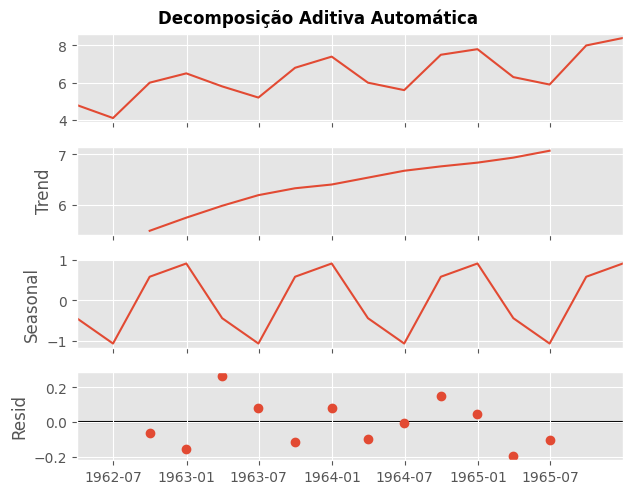

In [7]:
# Transformando em série temporal para o statsmodels
ts = pd.Series(df_trim['Zt'].values, index=pd.date_range('1962-01-01', periods=16, freq='QE'))
result = seasonal_decompose(ts, model='additive')

result.plot()
plt.suptitle('Decomposição Aditiva Automática', weight='semibold', y=1.02)
plt.show()

## 4. Decomposição Automática (Statsmodels)
Verificação dos resultados usando a biblioteca padrão.

In [5]:
# 1. Obter a Tendência (MA Centrada)
df_trim = pd.DataFrame({'Zt': [4.8, 4.1, 6.0, 6.5, 5.8, 5.2, 6.8, 7.4, 6.0, 5.6, 7.5, 7.8, 6.3, 5.9, 8.0, 8.4]})
df_trim['MA_Centrada'] = df_trim['Zt'].rolling(window=4).mean().rolling(window=2).mean().shift(-2)

# 2. Calcular os Resíduos (Zt - T_hat)
df_trim['Residuos'] = df_trim['Zt'] - df_trim['MA_Centrada']

# 3. Média dos resíduos por trimestre
df_trim['Trimestre'] = (df_trim.index % 4) + 1
s_bruto = df_trim.groupby('Trimestre')['Residuos'].mean()

# 4. Ajuste para que a soma seja ZERO (Sj = Dj - média(Dj))
s_ajustado = s_bruto - s_bruto.mean()

print("Constantes Sazonais Calculadas:")
for i, val in s_ajustado.items():
    print(f"Trimestre {i} (S{i}): {val:.4f}")

Constantes Sazonais Calculadas:
Trimestre 1 (S1): -0.4396
Trimestre 2 (S2): -1.0688
Trimestre 3 (S3): 0.5896
Trimestre 4 (S4): 0.9188


## 3. Exercício 4: Cálculo Manual das Constantes Sazonais
Memorial de cálculo para dados trimestrais.

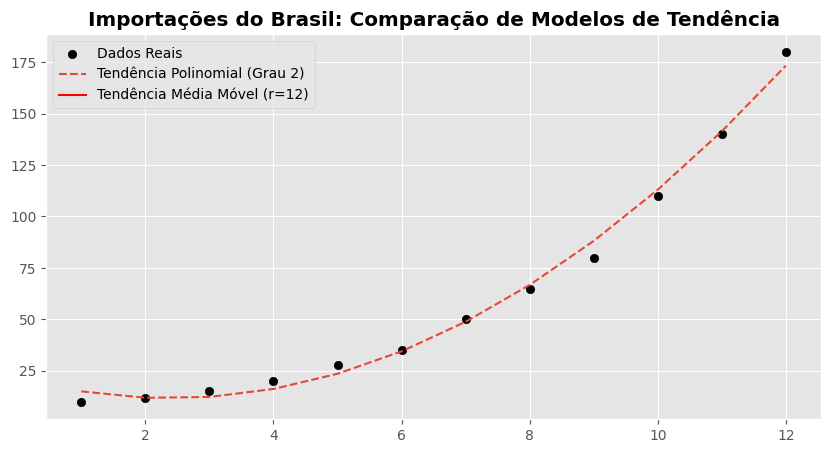

In [4]:
# Criando um eixo de tempo t
df_imp = pd.DataFrame({'Valor': [10, 12, 15, 20, 28, 35, 50, 65, 80, 110, 140, 180]}) # Exemplo
df_imp['t'] = np.arange(1, len(df_imp) + 1)

# Ajuste Polinomial de 2ª Ordem: Tt = b0 + b1*t + b2*t^2
coeffs = np.polyfit(df_imp['t'], df_imp['Valor'], 2)
poly_trend = np.polyval(coeffs, df_imp['t'])

# Média Móvel de 12 meses (r=12)
ma_12 = df_imp['Valor'].rolling(window=12, center=True).mean()

plt.figure(figsize=(10, 5))
plt.scatter(df_imp['t'], df_imp['Valor'], label='Dados Reais', color='black')
plt.plot(df_imp['t'], poly_trend, label='Tendência Polinomial (Grau 2)', linestyle='--')
plt.plot(df_imp['t'], ma_12, label='Tendência Média Móvel (r=12)', color='red')
plt.title('Importações do Brasil: Comparação de Modelos de Tendência')
plt.legend()
plt.show()

## 2. Exercício 3: Importações do Brasil (1968-1974)
Comparação entre Tendência Polinomial (2ª ordem) e Média Móvel (r=12).

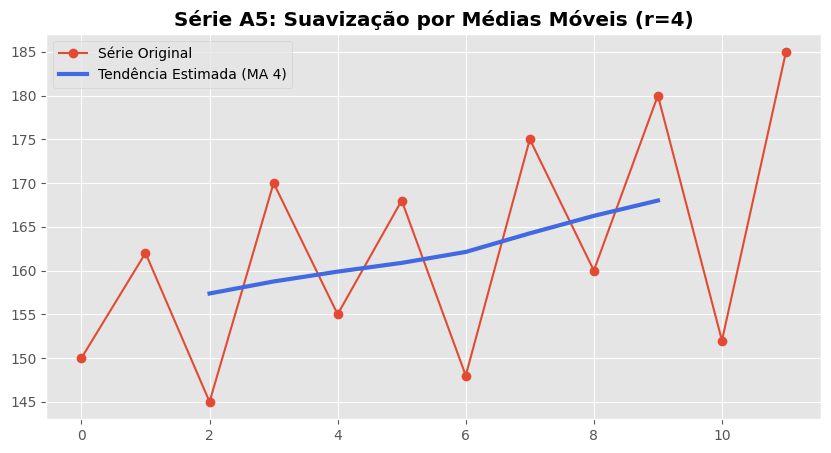

In [3]:
# Simulando a criação da série A5 (Substitua pela carga do seu CSV)
data_a5 = [150, 162, 145, 170, 155, 168, 148, 175, 160, 180, 152, 185] 
df_a5 = pd.DataFrame(data_a5, columns=['Consumo'])

# Cálculo da Média Móvel Centrada (r=4)
# Para r par, fazemos a média de duas médias móveis para centralizar
ma_4 = df_a5['Consumo'].rolling(window=4).mean()
t_hat = ma_4.rolling(window=2).mean().shift(-2)

plt.figure(figsize=(10, 5))
plt.plot(df_a5['Consumo'], label='Série Original', marker='o')
plt.plot(t_hat, label='Tendência Estimada (MA 4)', linewidth=3, color='royalblue')
plt.title('Série A5: Suavização por Médias Móveis (r=4)')
plt.legend()
plt.show()

## 1. Exercício 1: Suavização da Série A5 (Energia Elétrica)
O objetivo é obter um estimador suavizado de $T_t$ utilizando médias móveis de 4 termos ($r=4$).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Configurações estéticas para o seu portfólio (Semibold para títulos)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titleweight'] = 'semibold'
plt.style.use('ggplot')

# Portfólio 2: Tendência e Sazonalidade
**Disciplina:** Séries Temporais  
**Objetivo:** Decomposição de séries, estimativa de tendência e cálculo de constantes sazonais.